# Diseño de Experimentos

**Curso:** Análisis de Datos  
**Tema:** Planeación, Diseño Completamente Aleatorizado y Comparaciones Múltiples

---

## Contenido

1. **Planeación de un Diseño de Experimentos**
   - Conceptos básicos: objetivos y estrategias de diseño
   - Identificación de variables independientes y dependientes
   - Estrategias de aleatorización y control

2. **Diseño Completamente Aleatorizado (DCA)**
   - Fundamentos del diseño completamente aleatorizado
   - Análisis de Varianza (ANOVA): fundamentos y aplicación
   - Análisis e interpretación de los resultados experimentales

3. **Comparaciones Múltiples**
   - Métodos de comparaciones múltiples (Tukey, Bonferroni, otros)
   - Análisis e interpretación de resultados


## Librerías necesarias

Las siguientes librerías de Python serán utilizadas a lo largo del taller.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style="whitegrid", palette="Set2")
print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


---
# 1. Planeación de un Diseño de Experimentos

## 1.1 Conceptos Básicos de Diseño Experimental

Un **experimento** es una prueba o conjunto de pruebas en las que se realizan cambios deliberados en las variables de entrada de un proceso o sistema con el fin de observar e identificar los cambios en la respuesta de salida.

### ¿Por qué diseñar experimentos?

El diseño de experimentos (DoE, *Design of Experiments*) permite:
- **Identificar** los factores que más influyen en una respuesta.
- **Optimizar** el valor de una respuesta.
- **Reducir** la variabilidad de procesos.
- **Minimizar** el costo experimental al reducir el número de pruebas necesarias.

### Etapas en la planeación de un experimento

| Etapa | Descripción |
|-------|-------------|
| 1. Definir el problema | ¿Qué pregunta se quiere responder? |
| 2. Definir objetivos | Hipótesis que se desea probar |
| 3. Seleccionar variables | Factores (entrada) y respuesta (salida) |
| 4. Elegir el diseño | DCA, bloques, factorial, etc. |
| 5. Ejecutar el experimento | Recolectar datos con el plan definido |
| 6. Analizar los datos | ANOVA, comparaciones múltiples |
| 7. Interpretar y concluir | Tomar decisiones basadas en resultados |

### Principios fundamentales

- **Replicación:** repetir el experimento bajo las mismas condiciones para estimar el error experimental.
- **Aleatorización:** asignar tratamientos al azar para eliminar sesgo sistemático.
- **Control local (bloqueo):** agrupar unidades experimentales similares para reducir variabilidad no explicada.

## 1.2 Identificación de Variables

### Variables independientes (factores)
Son las variables que el investigador **manipula deliberadamente**. Se clasifican en:

- **Factores controlables:** Pueden fijarse a niveles específicos (temperatura, dosis, método).
- **Factores de ruido:** Difíciles de controlar; se incluyen en el diseño para medir su efecto.

### Variables dependientes (respuesta)
Son las variables que se **miden u observan** como resultado del experimento. Deben ser:
- Medibles de forma objetiva.
- Sensibles a los cambios en los factores.
- Representativas del objetivo del experimento.

### Variables de control (covariables)
Variables que se mantienen constantes o cuyo efecto se desea eliminar del análisis (e.g., peso inicial de los sujetos, condiciones ambientales).

---

### Ejemplo práctico

> **Contexto:** Se desea evaluar el efecto del tipo de fertilizante sobre el rendimiento de trigo (kg/ha).

| Elemento | Descripción |
|----------|-------------|
| **Variable independiente (factor)** | Tipo de fertilizante (A, B, C, D) |
| **Niveles del factor** | 4 tratamientos |
| **Variable dependiente (respuesta)** | Rendimiento en kg/ha |
| **Variables de control** | Variedad de trigo, riego, clima |
| **Unidad experimental** | Parcela de terreno (5×5 m) |

In [2]:
# ------------------------------------------------------------------
# Ejemplo: estructura de datos del experimento de fertilizantes
# ------------------------------------------------------------------
np.random.seed(42)

# Definición del experimento
tratamientos = ['Fertilizante A', 'Fertilizante B', 'Fertilizante C', 'Fertilizante D']
n_replicas = 5  # réplicas por tratamiento

# Medias reales simuladas (kg/ha) y desviación estándar del proceso
medias_reales = {'Fertilizante A': 380, 'Fertilizante B': 420,
                 'Fertilizante C': 460, 'Fertilizante D': 400}
sigma = 30

# Generar datos
registros = []
for trat, media in medias_reales.items():
    for rep in range(1, n_replicas + 1):
        rendimiento = np.random.normal(loc=media, scale=sigma)
        registros.append({'Tratamiento': trat, 'Replica': rep,
                          'Rendimiento_kgha': round(rendimiento, 2)})

df = pd.DataFrame(registros)
print("Estructura del conjunto de datos:")
print(df.to_string(index=False))
print(f"\nTotal de observaciones: {len(df)}")
print(f"Tratamientos: {df['Tratamiento'].nunique()}")
print(f"Réplicas por tratamiento: {n_replicas}")

Estructura del conjunto de datos:
   Tratamiento  Replica  Rendimiento_kgha
Fertilizante A        1            394.90
Fertilizante A        2            375.85
Fertilizante A        3            399.43
Fertilizante A        4            425.69
Fertilizante A        5            372.98
Fertilizante B        1            412.98
Fertilizante B        2            467.38
Fertilizante B        3            443.02
Fertilizante B        4            405.92
Fertilizante B        5            436.28
Fertilizante C        1            446.10
Fertilizante C        2            446.03
Fertilizante C        3            467.26
Fertilizante C        4            402.60
Fertilizante C        5            408.25
Fertilizante D        1            383.13
Fertilizante D        2            369.62
Fertilizante D        3            409.43
Fertilizante D        4            372.76
Fertilizante D        5            357.63

Total de observaciones: 20
Tratamientos: 4
Réplicas por tratamiento: 5


## 1.3 Estrategias de Aleatorización y Control

### ¿Por qué aleatorizar?

La **aleatorización** garantiza que las unidades experimentales son asignadas a los tratamientos de forma independiente y sin sesgo. Esto es esencial para que los supuestos estadísticos del ANOVA sean válidos.

> **Sin aleatorización:** los efectos de variables no controladas (orden de ejecución, operador, lote de material) se confunden con los efectos del tratamiento.

### Tipos de aleatorización

| Tipo | Descripción | Cuándo usarla |
|------|-------------|---------------|
| **Aleatorización completa** | Se sortean todos los tratamientos sobre todas las UE | Condiciones homogéneas |
| **Aleatorización restringida (bloques)** | Se aleatoriza dentro de grupos homogéneos | Existe una fuente de variación conocida |
| **Aleatorización por secuencia** | Solo se aleatoriza el orden de ejecución | Experimentos secuenciales |

### Control experimental

El **control** busca reducir la variabilidad no explicada:

- **Control físico:** mantener constantes las variables de ruido conocidas.
- **Control estadístico (bloqueo):** incluir la fuente de variación como factor de bloqueo en el modelo.
- **Réplicas verdaderas:** repetir de forma independiente el tratamiento, no simplemente medir varias veces la misma unidad experimental.

In [3]:
# ------------------------------------------------------------------
# Ejemplo de aleatorización: orden de ejecución de los experimentos
# ------------------------------------------------------------------
np.random.seed(0)

# Se tienen 20 unidades experimentales (5 réplicas × 4 tratamientos)
n_trat = 4
n_rep  = 5

unidades = []
for t in range(1, n_trat + 1):
    for r in range(1, n_rep + 1):
        unidades.append(f'T{t}-R{r}')

# Aleatorización completa del orden de ejecución
orden_aleatorio = np.random.permutation(unidades)

plan = pd.DataFrame({
    'Orden_ejecucion': range(1, len(unidades) + 1),
    'Unidad_experimental': orden_aleatorio
})

print("Plan de aleatorización completa:")
print(plan.to_string(index=False))
print("\nCada tratamiento aparece exactamente", n_rep, "veces, en orden aleatorio.")

Plan de aleatorización completa:
 Orden_ejecucion Unidad_experimental
               1               T4-R4
               2               T1-R2
               3               T4-R5
               4               T2-R4
               5               T3-R1
               6               T4-R3
               7               T2-R2
               8               T3-R4
               9               T1-R5
              10               T1-R3
              11               T2-R1
              12               T3-R5
              13               T2-R5
              14               T2-R3
              15               T4-R2
              16               T3-R2
              17               T1-R4
              18               T1-R1
              19               T4-R1
              20               T3-R3

Cada tratamiento aparece exactamente 5 veces, en orden aleatorio.


---
# 2. Diseño Completamente Aleatorizado (DCA)

## 2.1 Fundamentos del Diseño Completamente Aleatorizado

El **Diseño Completamente Aleatorizado (DCA)** es la estructura experimental más simple. Se utiliza cuando:

- Las unidades experimentales son **homogéneas** (no hay fuente obvia de variación en el material experimental).
- Hay un **solo factor** de interés con $k \geq 2$ niveles (tratamientos).
- Las observaciones se asignan **completamente al azar** a los tratamientos.

### Modelo estadístico

El modelo lineal del DCA es:

$$y_{ij} = \mu + \tau_i + \varepsilon_{ij}$$

donde:
- $y_{ij}$ = observación $j$ del tratamiento $i$
- $\mu$ = media general
- $\tau_i$ = efecto del tratamiento $i$ ($\sum \tau_i = 0$)
- $\varepsilon_{ij} \sim N(0, \sigma^2)$ = error aleatorio

### Hipótesis de interés

$$H_0: \mu_1 = \mu_2 = \cdots = \mu_k \quad \text{(todos los tratamientos son iguales)}$$
$$H_1: \text{al menos un par } \mu_i \neq \mu_j$$

### Supuestos del modelo

| Supuesto | Descripción | Verificación |
|----------|-------------|--------------|
| **Normalidad** | Los errores siguen distribución normal | Shapiro-Wilk, Q-Q plot |
| **Homogeneidad de varianzas** | $\sigma_1^2 = \sigma_2^2 = \cdots = \sigma_k^2$ | Levene, Bartlett |
| **Independencia** | Las observaciones son independientes | Diseño experimental correcto |

In [ ]:
# ------------------------------------------------------------------
# Visualización exploratoria del DCA: boxplots y descripción
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
sns.boxplot(data=df, x='Tratamiento', y='Rendimiento_kgha', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución del rendimiento por tratamiento')
axes[0].set_xlabel('Tratamiento')
axes[0].set_ylabel('Rendimiento (kg/ha)')

# Diagrama de puntos (strip plot) superpuesto
sns.stripplot(data=df, x='Tratamiento', y='Rendimiento_kgha', ax=axes[0],
              color='black', alpha=0.6, jitter=True, size=6)

# Medias por tratamiento
medias = df.groupby('Tratamiento')['Rendimiento_kgha'].mean()
medias.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', 4), edgecolor='black')
axes[1].set_title('Media del rendimiento por tratamiento')
axes[1].set_xlabel('Tratamiento')
axes[1].set_ylabel('Rendimiento promedio (kg/ha)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("\nEstadísticas descriptivas por tratamiento:")
print(df.groupby('Tratamiento')['Rendimiento_kgha']
        .agg(['count', 'mean', 'std', 'min', 'max'])
        .round(2)
        .rename(columns={'count': 'n', 'mean': 'Media', 'std': 'DE',
                         'min': 'Mínimo', 'max': 'Máximo'}))

## 2.2 Análisis de Varianza (ANOVA)

### ¿Qué hace el ANOVA?

El ANOVA descompone la **variabilidad total** de los datos en dos componentes:

$$SS_{Total} = SS_{Tratamientos} + SS_{Error}$$

| Fuente | Suma de cuadrados | Grados de libertad | Cuadrado medio | F |
|--------|------------------|--------------------|----------------|---|
| Tratamientos | $SS_T = n\sum_i(\bar{y}_{i\cdot} - \bar{y}_{\cdot\cdot})^2$ | $k-1$ | $MS_T = SS_T/(k-1)$ | $F = MS_T/MS_E$ |
| Error | $SS_E = \sum_i\sum_j(y_{ij} - \bar{y}_{i\cdot})^2$ | $N-k$ | $MS_E = SS_E/(N-k)$ | |
| Total | $SS_{Tot}$ | $N-1$ | | |

### Estadístico de prueba

$$F_0 = \frac{MS_{Tratamientos}}{MS_{Error}} \sim F_{k-1,\, N-k}$$

- Si $F_0 > F_{\alpha, k-1, N-k}$ → **Rechazar $H_0$**: al menos dos tratamientos son diferentes.
- Si $p\text{-valor} < \alpha$ → **Rechazar $H_0$**.

> **Nota:** El ANOVA solo indica que *existe* diferencia entre medias, no *cuál par* de medias difiere. Para ello se usan las **comparaciones múltiples** (Sección 3).

In [4]:
# ------------------------------------------------------------------
# ANOVA de una vía usando statsmodels
# ------------------------------------------------------------------
# Ajustar modelo: Rendimiento ~ Tratamiento
modelo = ols('Rendimiento_kgha ~ C(Tratamiento)', data=df).fit()

# Tabla ANOVA
tabla_anova = anova_lm(modelo, typ=1)
tabla_anova.index = ['Tratamiento', 'Error (Residuo)']
tabla_anova.columns = ['GL', 'SS', 'MS', 'F', 'p-valor']

print("=" * 65)
print("           TABLA ANOVA – Diseño Completamente Aleatorizado")
print("=" * 65)
print(tabla_anova.round(4).to_string())
print("=" * 65)

alpha = 0.05
p_valor = tabla_anova.loc['Tratamiento', 'p-valor']
F_obs   = tabla_anova.loc['Tratamiento', 'F']

print(f"\nF observado  = {F_obs:.4f}")
print(f"p-valor      = {p_valor:.4f}")
print(f"Nivel α      = {alpha}")
print()
if p_valor < alpha:
    print("→ Conclusión: Se RECHAZA H₀. Existe evidencia estadística de que al menos")
    print("  dos tratamientos producen rendimientos medios significativamente diferentes.")
else:
    print("→ Conclusión: No se rechaza H₀. No hay evidencia de diferencia entre tratamientos.")

           TABLA ANOVA – Diseño Completamente Aleatorizado
                   GL          SS         MS       F  p-valor
Tratamiento       3.0  11836.8034  3945.6011  7.1701   0.0029
Error (Residuo)  16.0   8804.5813   550.2863     NaN      NaN

F observado  = 7.1701
p-valor      = 0.0029
Nivel α      = 0.05

→ Conclusión: Se RECHAZA H₀. Existe evidencia estadística de que al menos
  dos tratamientos producen rendimientos medios significativamente diferentes.


## 2.3 Verificación de Supuestos e Interpretación de Resultados

Antes de confiar en los resultados del ANOVA es obligatorio verificar los tres supuestos del modelo:

### Verificación de supuestos

| Supuesto | Prueba formal | Gráfico |
|----------|--------------|---------|
| **Normalidad de residuos** | Shapiro-Wilk (n < 50) | Q-Q plot |
| **Homogeneidad de varianzas** | Levene (robusta) | Residuos vs. ajustados |
| **Independencia** | (garantizada por el diseño) | Residuos vs. orden |

### Interpretar el ANOVA

- **$R^2$ (coeficiente de determinación):** proporción de variabilidad total explicada por el factor.
- **$MS_E$ (cuadrado medio del error):** estimación de $\sigma^2$; mide la variabilidad residual.
- **Un $F$ grande y $p < \alpha$** indica que las diferencias entre tratamientos son reales, no solo ruido.

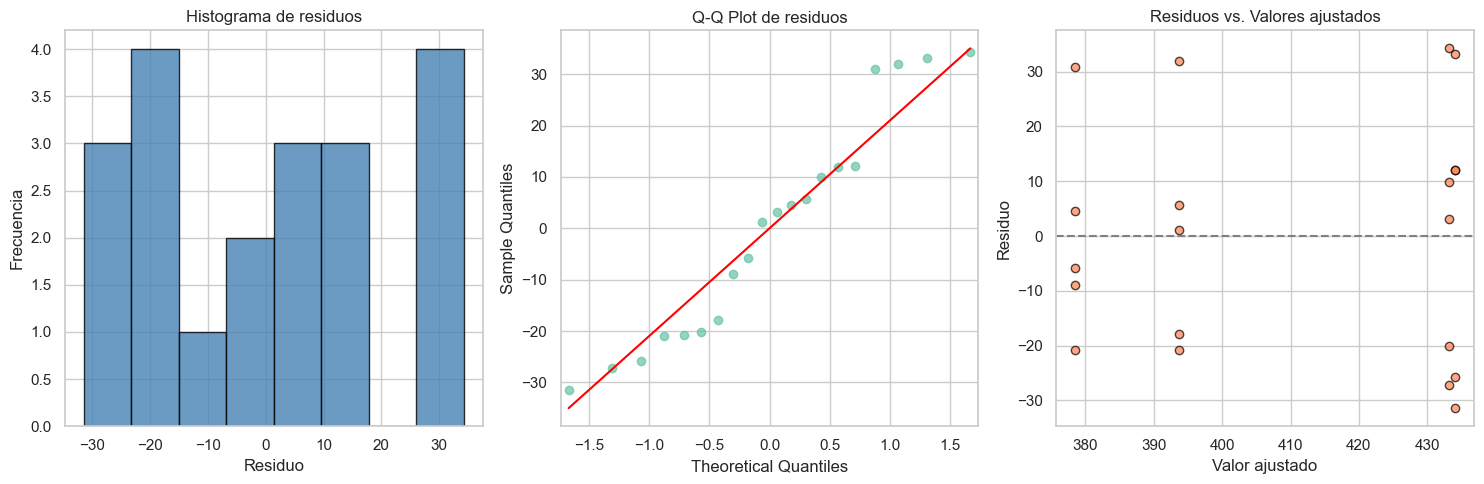

Prueba de normalidad (Shapiro-Wilk):
  W = 0.9250,  p-valor = 0.1237 → Normalidad OK ✓

Prueba de homogeneidad de varianzas (Levene):
  W = 0.2180,  p-valor = 0.8825 → Varianzas iguales OK ✓

Coeficiente de determinación del modelo: R² = 0.5735
  El factor 'Tratamiento' explica el 57.3% de la variabilidad total.


In [5]:
# ------------------------------------------------------------------
# Diagnóstico del modelo: verificación de supuestos
# ------------------------------------------------------------------
residuos   = modelo.resid
ajustados  = modelo.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Histograma de residuos
axes[0].hist(residuos, bins=8, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].set_title('Histograma de residuos')
axes[0].set_xlabel('Residuo')
axes[0].set_ylabel('Frecuencia')

# 2. Q-Q plot (normalidad)
sm.qqplot(residuos, line='s', ax=axes[1], alpha=0.7)
axes[1].set_title('Q-Q Plot de residuos')

# 3. Residuos vs. valores ajustados (homogeneidad de varianzas)
axes[2].scatter(ajustados, residuos, color='coral', edgecolors='black', alpha=0.7)
axes[2].axhline(0, linestyle='--', color='gray')
axes[2].set_title('Residuos vs. Valores ajustados')
axes[2].set_xlabel('Valor ajustado')
axes[2].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

# Prueba de normalidad (Shapiro-Wilk)
stat_sw, p_sw = stats.shapiro(residuos)
# Prueba de homogeneidad de varianzas (Levene)
grupos = [grp['Rendimiento_kgha'].values for _, grp in df.groupby('Tratamiento')]
stat_lev, p_lev = stats.levene(*grupos)

print("Prueba de normalidad (Shapiro-Wilk):")
print(f"  W = {stat_sw:.4f},  p-valor = {p_sw:.4f}",
      "→ Normalidad OK ✓" if p_sw > 0.05 else "→ Posible violación de normalidad ⚠")

print("\nPrueba de homogeneidad de varianzas (Levene):")
print(f"  W = {stat_lev:.4f},  p-valor = {p_lev:.4f}",
      "→ Varianzas iguales OK ✓" if p_lev > 0.05 else "→ Posible heterogeneidad de varianzas ⚠")

print(f"\nCoeficiente de determinación del modelo: R² = {modelo.rsquared:.4f}")
print(f"  El factor 'Tratamiento' explica el {modelo.rsquared*100:.1f}% de la variabilidad total.")

---
# 3. Comparaciones Múltiples

## 3.1 El Problema de Comparaciones Múltiples

Cuando el ANOVA rechaza $H_0$, sabemos que **al menos una pareja** de medias difiere, pero no *cuál*. La solución ingenua de aplicar pruebas $t$ para todos los pares posibles **infla el error de Tipo I**.

### Tasa de error familiar (*Family-Wise Error Rate*, FWER)

Si se hacen $m$ comparaciones simultáneas con nivel $\alpha$ cada una:

$$\text{FWER} = 1 - (1-\alpha)^m$$

**Ejemplo:** Con $k=4$ tratamientos hay $\binom{4}{2}=6$ pares. Si $\alpha=0.05$ por prueba:  
$$\text{FWER} = 1 - (0.95)^6 \approx 0.265$$

Es decir, hay un **26.5%** de probabilidad de cometer al menos un error de Tipo I.

---

## 3.2 Métodos de Comparaciones Múltiples

### Método de Tukey (HSD – Honest Significant Difference)

- Controla la FWER al nivel $\alpha$ exactamente bajo balanceo.
- Compara **todos los pares posibles** usando el rango estudentizado:

$$q = \frac{\bar{y}_{i\cdot} - \bar{y}_{j\cdot}}{\sqrt{MS_E / n}}$$

- **Uso recomendado:** Comparación exhaustiva de todos los pares de medias con muestras balanceadas.

### Método de Bonferroni

- Ajusta el nivel de significancia dividiendo entre el número de comparaciones: $\alpha^* = \alpha / m$.
- Es **conservador** (aumenta el error de Tipo II) pero muy flexible.
- **Uso recomendado:** Pocos contrastes planificados a priori, o cuando el diseño está desbalanceado.

### Otros métodos

| Método | Característica |
|--------|---------------|
| **Holm-Bonferroni** | Extensión secuencial de Bonferroni, menos conservador |
| **Scheffé** | Muy conservador; válido para cualquier contraste lineal |
| **Dunnett** | Compara cada tratamiento contra un control específico |
| **Fisher LSD** | El menos conservador; recomendado solo tras ANOVA significativo con $k=3$ |

In [6]:
# ------------------------------------------------------------------
# Prueba de Tukey HSD
# ------------------------------------------------------------------
mc = MultiComparison(df['Rendimiento_kgha'], df['Tratamiento'])
resultado_tukey = mc.tukeyhsd(alpha=0.05)

print("=" * 65)
print("           PRUEBA DE TUKEY HSD  (α = 0.05)")
print("=" * 65)
print(resultado_tukey.summary())
print()

# Tabla de resultados en DataFrame
tukey_df = pd.DataFrame(
    data=resultado_tukey._results_table.data[1:],
    columns=resultado_tukey._results_table.data[0]
)
print("Resumen de diferencias de medias:")
print(tukey_df[['group1', 'group2', 'meandiff', 'p-adj', 'lower', 'upper', 'reject']].to_string(index=False))

           PRUEBA DE TUKEY HSD  (α = 0.05)
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
    group1         group2     meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------
Fertilizante A Fertilizante B   39.346 0.0742  -3.1008  81.7928  False
Fertilizante A Fertilizante C   40.278  0.066  -2.1688  82.7248  False
Fertilizante A Fertilizante D  -15.256 0.7357 -57.7028  27.1908  False
Fertilizante B Fertilizante C    0.932 0.9999 -41.5148  43.3788  False
Fertilizante B Fertilizante D  -54.602 0.0098 -97.0488 -12.1552   True
Fertilizante C Fertilizante D  -55.534 0.0086 -97.9808 -13.0872   True
----------------------------------------------------------------------

Resumen de diferencias de medias:
        group1         group2  meandiff  p-adj    lower    upper  reject
Fertilizante A Fertilizante B    39.346 0.0742  -3.1008  81.7928   False
Fertilizante A Fertilizante C    40.278 0.0660  -2.1688  82.7248  

In [7]:
# ------------------------------------------------------------------
# Método de Bonferroni usando scipy y multipletests
# ------------------------------------------------------------------
from itertools import combinations

grupos_nombres = df['Tratamiento'].unique()
pares = list(combinations(grupos_nombres, 2))

# p-valores crudos de prueba t para cada par
p_crudos = []
for g1, g2 in pares:
    x1 = df.loc[df['Tratamiento'] == g1, 'Rendimiento_kgha']
    x2 = df.loc[df['Tratamiento'] == g2, 'Rendimiento_kgha']
    _, p = stats.ttest_ind(x1, x2)
    p_crudos.append(p)

# Corrección Bonferroni y Holm-Bonferroni
reject_bon, p_bon, _, _  = multipletests(p_crudos, alpha=0.05, method='bonferroni')
reject_holm, p_holm, _, _ = multipletests(p_crudos, alpha=0.05, method='holm')

resultados_mc = pd.DataFrame({
    'Par':              [f"{g1} vs {g2}" for g1, g2 in pares],
    'p_crudo':          [round(p, 4) for p in p_crudos],
    'p_Bonferroni':     [round(p, 4) for p in p_bon],
    'Sig_Bonferroni':   ['Sí *' if r else 'No' for r in reject_bon],
    'p_Holm':           [round(p, 4) for p in p_holm],
    'Sig_Holm':         ['Sí *' if r else 'No' for r in reject_holm],
})

print("=" * 75)
print("  COMPARACIONES MÚLTIPLES: Bonferroni y Holm-Bonferroni  (α = 0.05)")
print("=" * 75)
print(resultados_mc.to_string(index=False))
print("\n* = diferencia estadísticamente significativa")

  COMPARACIONES MÚLTIPLES: Bonferroni y Holm-Bonferroni  (α = 0.05)
                             Par  p_crudo  p_Bonferroni Sig_Bonferroni  p_Holm Sig_Holm
Fertilizante A vs Fertilizante B   0.0269        0.1613             No  0.1075       No
Fertilizante A vs Fertilizante C   0.0323        0.1939             No  0.1075       No
Fertilizante A vs Fertilizante D   0.2711        1.0000             No  0.5422       No
Fertilizante B vs Fertilizante C   0.9565        1.0000             No  0.9565       No
Fertilizante B vs Fertilizante D   0.0046        0.0279           Sí *  0.0279     Sí *
Fertilizante C vs Fertilizante D   0.0063        0.0377           Sí *  0.0314     Sí *

* = diferencia estadísticamente significativa


## 3.3 Visualización e Interpretación de Resultados

La interpretación de los resultados de comparaciones múltiples incluye:

1. **Identificar qué pares difieren significativamente** (columna `reject = True` en Tukey, o `Sig = Sí` en Bonferroni).
2. **Estimar la magnitud de la diferencia** (`meandiff`) y su intervalo de confianza (`lower`, `upper`).
3. **Representar gráficamente** los grupos con letras de agrupamiento: tratamientos que comparten la misma letra **no** difieren significativamente.

> **Regla práctica:** Si el intervalo de confianza de la diferencia entre dos medias **no incluye el cero**, la diferencia es estadísticamente significativa.

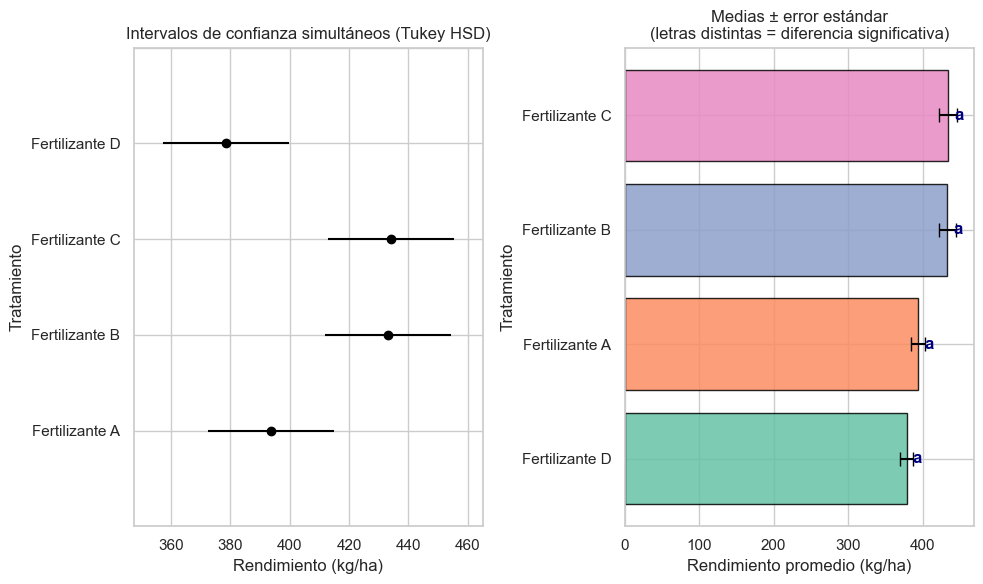

In [8]:
# ------------------------------------------------------------------
# Gráfico de Tukey HSD con intervalos de confianza simultáneos
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel izquierdo: gráfico de Tukey ---
resultado_tukey.plot_simultaneous(ax=axes[0], ylabel='Tratamiento', xlabel='Rendimiento (kg/ha)')
axes[0].set_title('Intervalos de confianza simultáneos (Tukey HSD)')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.4)

# --- Panel derecho: medias con letras de significancia ---
medias_ord = df.groupby('Tratamiento')['Rendimiento_kgha'].mean().sort_values()
se_ord = df.groupby('Tratamiento')['Rendimiento_kgha'].sem()

# Letras de agrupamiento (determinadas manualmente a partir de Tukey)
# En un análisis real se extraen programáticamente; aquí se asignan según los resultados
letras = {}
tukey_reject = {(str(r[0]), str(r[1])): bool(r[6]) 
                for r in resultado_tukey._results_table.data[1:]}

trat_list = list(medias_ord.index)
grupos_letras = {t: set() for t in trat_list}
letra_actual = ord('a')
asignada = {t: False for t in trat_list}

for i, t1 in enumerate(trat_list):
    for j, t2 in enumerate(trat_list):
        if i >= j:
            continue
        par = (t1, t2) if (t1, t2) in tukey_reject else (t2, t1)
        if par in tukey_reject and not tukey_reject[par]:
            grupos_letras[t1].add(chr(letra_actual))
            grupos_letras[t2].add(chr(letra_actual))

# Si algún tratamiento no tiene letra, asignar una nueva
for t in trat_list:
    if not grupos_letras[t]:
        grupos_letras[t].add(chr(letra_actual))
    letra_actual += 1

bars = axes[1].barh(trat_list, medias_ord.values,
                    xerr=se_ord[trat_list].values, capsize=5,
                    color=sns.color_palette('Set2', len(trat_list)),
                    edgecolor='black', alpha=0.85)

for i, (t, media) in enumerate(zip(trat_list, medias_ord.values)):
    letra = ''.join(sorted(grupos_letras[t]))
    axes[1].text(media + 8, i, letra, va='center', fontsize=12, fontweight='bold', color='navy')

axes[1].set_title('Medias ± error estándar\n(letras distintas = diferencia significativa)')
axes[1].set_xlabel('Rendimiento promedio (kg/ha)')
axes[1].set_ylabel('Tratamiento')

plt.tight_layout()
plt.show()

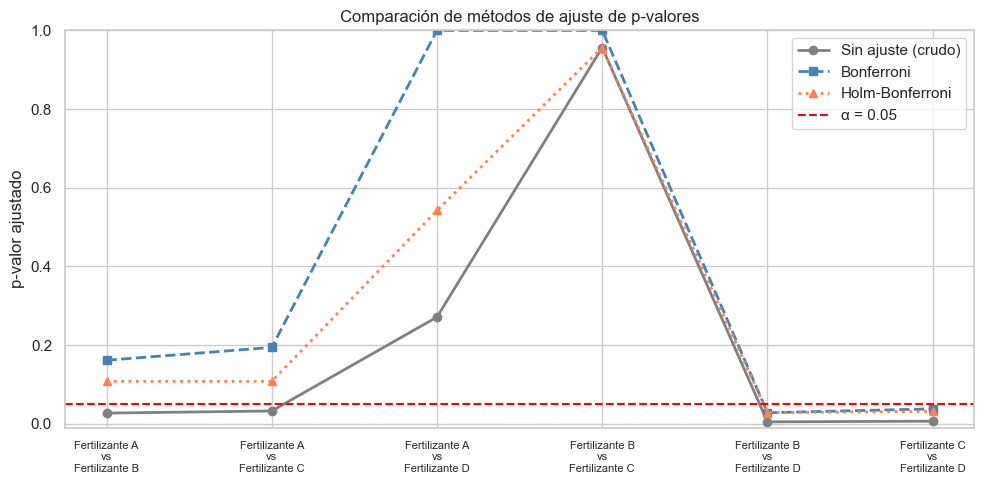


Conclusión:
Los pares con p-valor ajustado < 0.05 presentan diferencias estadísticamente significativas.
Tukey HSD y Holm-Bonferroni generalmente ofrecen mayor potencia que Bonferroni clásico.


In [9]:
# ------------------------------------------------------------------
# Comparación visual de p-valores ajustados por los tres métodos
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(pares))
etiquetas = [f"{g1[:4]}…\nvs {g2[:4]}…" for g1, g2 in pares]

ax.plot(x, p_crudos, 'o-', label='Sin ajuste (crudo)', color='gray', linewidth=2)
ax.plot(x, p_bon,    's--', label='Bonferroni',          color='steelblue', linewidth=2)
ax.plot(x, p_holm,   '^:', label='Holm-Bonferroni',      color='coral', linewidth=2)
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')

ax.set_xticks(list(x))
ax.set_xticklabels([f"{g1}\nvs\n{g2}" for g1, g2 in pares], fontsize=8)
ax.set_ylabel('p-valor ajustado')
ax.set_title('Comparación de métodos de ajuste de p-valores')
ax.legend()
ax.set_ylim(-0.01, 1.0)
plt.tight_layout()
plt.show()

print("\nConclusión:")
print("Los pares con p-valor ajustado < 0.05 presentan diferencias estadísticamente significativas.")
print("Tukey HSD y Holm-Bonferroni generalmente ofrecen mayor potencia que Bonferroni clásico.")

---
# Resumen del Tema


| Sección | Concepto clave | Herramienta en Python |
|---------|---------------|----------------------|
| **Planeación** | Objetivos, variables, aleatorización | `numpy.random.permutation` |
| **DCA – Modelo** | $y_{ij} = \mu + \tau_i + \varepsilon_{ij}$ | `statsmodels.formula.api.ols` |
| **ANOVA** | Descomposición $SS_{Total} = SS_T + SS_E$ | `anova_lm` |
| **Supuestos** | Normalidad, homocedasticidad, independencia | `scipy.stats.shapiro`, `levene` |
| **Tukey HSD** | Controla FWER; todos los pares | `pairwise_tukeyhsd` |
| **Bonferroni** | $\alpha^* = \alpha/m$; conservador | `multipletests(..., method='bonferroni')` |
| **Holm-Bonferroni** | Secuencial; menor conservadurismo que Bonferroni | `multipletests(..., method='holm')` |

### Flujo de análisis recomendado

```
Planeación → Recolección de datos → Estadísticas descriptivas
    → ANOVA (prueba ómnibus)
        → Si p < α: Comparaciones múltiples (Tukey / Bonferroni)
        → Verificar supuestos (normalidad, homocedasticidad)
    → Interpretación y conclusiones
```

> **Recuerda:** La significancia estadística no implica relevancia práctica. Siempre acompaña los resultados con el tamaño del efecto y el contexto del problema.